# Scalping ETH/USD — Análisis técnico multi-temporalidad (5m / 15m / 1h)

Este notebook analiza las **últimas 90 velas** de ETH/USD en **tres temporalidades en paralelo — 5 minutos, 15 minutos y 1 hora** — y para cada una genera:

1. Una **señal de entrada** (COMPRA / VENTA / NEUTRAL) con una **probabilidad estimada**, calculada con un sistema de puntuación ponderado sobre varios indicadores técnicos y patrones de velas.
2. Niveles de **Stop Loss** y tres **Take Profit** (TP1/TP2/TP3), calculados con múltiplos de riesgo (R) sobre el ATR de esa misma temporalidad.

Al final se construye una **tabla comparativa** entre las tres temporalidades y un veredicto de **confluencia** (cuántas de las tres coinciden en la misma dirección), útil para no operar solo con la lectura de una única temporalidad.

Los gráficos usan **matplotlib** (interfaz orientada a objetos `fig, ax = plt.subplots()`, no la interfaz de estado `plt.plot()/plt.show()` global).

### Fuente de datos

Fuente principal: **Alpaca** (API de datos de cripto), usando `ALPACA_API_KEY_ID` / `ALPACA_API_SECRET_KEY` desde `.env`. Si Alpaca no responde (credenciales, permisos, red), cada temporalidad recurre automáticamente a la API pública de Binance (`api.binance.com`, sin necesidad de API key) como respaldo.

### ⚠️ Aviso importante

Herramienta educativa de apoyo al análisis, no asesoría financiera. La "probabilidad" es un **score heurístico ponderado**, no una probabilidad estadística calibrada. Valida con backtesting y gestión de riesgo propia antes de operar capital real.

## 1. Configuración

In [35]:
import os
import numpy as np
import pandas as pd
import requests
import ta
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from dotenv import load_dotenv

load_dotenv()

ALPACA_API_KEY_ID = os.getenv("ALPACA_API_KEY_ID", "")
ALPACA_API_SECRET_KEY = os.getenv("ALPACA_API_SECRET_KEY", "")

SYMBOL_ALPACA = "ETH/USD" #XAGUSD: XAG/USD
SYMBOL_BINANCE = "ETHUSDT" # XAGUSD: XAGUSDT

# --- Temporalidades a analizar en paralelo ---
TEMPORALIDADES = [
    {"etiqueta": "5 minutos", "tf_alpaca": "5Min", "tf_binance": "5m"},
    {"etiqueta": "15 minutos", "tf_alpaca": "15Min", "tf_binance": "15m"},
    {"etiqueta": "1 hora", "tf_alpaca": "1Hour", "tf_binance": "1h"},
]

N_VELAS = 90                  # velas objetivo del análisis (por temporalidad)
VELAS_BUFFER = 60             # velas extra de historial para que EMA50/RSI/etc. estén "calientes" desde la vela 1 de las N_VELAS

# --- Gestión de riesgo (scalping) ---
MULT_ATR_SL = 1.2             # distancia del Stop Loss en múltiplos de ATR14
RR_TP = (1.0, 1.8, 3.0)       # múltiplos de riesgo (R) para TP1, TP2, TP3
UMBRAL_SEÑAL = 60             # probabilidad mínima (%) para considerar señal COMPRA/VENTA en vez de NEUTRAL

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Obtención de datos (Alpaca → respaldo automático Binance)

In [36]:
def obtener_velas_alpaca(symbol, timeframe, limit):
    if not ALPACA_API_KEY_ID or not ALPACA_API_SECRET_KEY:
        raise ValueError("ALPACA_API_KEY_ID / ALPACA_API_SECRET_KEY no configuradas en .env")
    headers = {"APCA-API-KEY-ID": ALPACA_API_KEY_ID, "APCA-API-SECRET-KEY": ALPACA_API_SECRET_KEY}
    params = {"symbols": symbol, "timeframe": timeframe, "limit": limit, "sort": "asc"}
    r = requests.get("https://data.alpaca.markets/v1beta3/crypto/us/bars",
                      headers=headers, params=params, timeout=15)
    r.raise_for_status()
    bars = r.json()["bars"][symbol]
    df = pd.DataFrame(bars).rename(columns={"t": "timestamp", "o": "open", "h": "high",
                                              "l": "low", "c": "close", "v": "volume"})
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df.set_index("timestamp")[["open", "high", "low", "close", "volume"]]


def obtener_velas_binance(symbol, interval, limit):
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    r = requests.get("https://api.binance.com/api/v3/klines", params=params, timeout=15)
    r.raise_for_status()
    cols = ["open_time", "open", "high", "low", "close", "volume", "close_time",
            "qav", "trades", "tbbav", "tbqav", "ignore"]
    df = pd.DataFrame(r.json(), columns=cols)
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = df[c].astype(float)
    return df.set_index("timestamp")[["open", "high", "low", "close", "volume"]]


def obtener_velas(symbol_alpaca, symbol_binance, tf_alpaca, tf_binance, limit):
    try:
        df = obtener_velas_alpaca(symbol_alpaca, tf_alpaca, limit)
        return df, "Alpaca"
    except Exception as e:
        print(f"⚠️  Alpaca no disponible ({e}). Usando respaldo gratuito: Binance public API...")
        df = obtener_velas_binance(symbol_binance, tf_binance, limit)
        return df, "Binance (respaldo)"

## 3. Indicadores técnicos

EMAs (9/21/50), RSI(14), MACD, Bandas de Bollinger(20,2), ATR(14), Estocástico(14,3) y volumen relativo.

In [37]:
def calcular_indicadores(df):
    df = df.copy()
    df["ema9"] = ta.trend.EMAIndicator(df["close"], 9).ema_indicator()
    df["ema21"] = ta.trend.EMAIndicator(df["close"], 21).ema_indicator()
    df["ema50"] = ta.trend.EMAIndicator(df["close"], 50).ema_indicator()
    df["rsi14"] = ta.momentum.RSIIndicator(df["close"], 14).rsi()

    macd = ta.trend.MACD(df["close"])
    df["macd"] = macd.macd()
    df["macd_signal"] = macd.macd_signal()
    df["macd_hist"] = macd.macd_diff()

    bb = ta.volatility.BollingerBands(df["close"], 20, 2)
    df["bb_high"] = bb.bollinger_hband()
    df["bb_low"] = bb.bollinger_lband()
    df["bb_mid"] = bb.bollinger_mavg()

    df["atr14"] = ta.volatility.AverageTrueRange(df["high"], df["low"], df["close"], 14).average_true_range()

    stoch = ta.momentum.StochasticOscillator(df["high"], df["low"], df["close"], 14, 3)
    df["stoch_k"] = stoch.stoch()
    df["stoch_d"] = stoch.stoch_signal()

    df["vol_sma20"] = df["volume"].rolling(20).mean()
    df["vol_rel"] = df["volume"] / df["vol_sma20"]
    return df

## 4. Patrones de velas (price action)

Detección vectorizada de envolventes (engulfing), martillo/estrella fugaz (pin bars) y doji.

In [38]:
def detectar_patrones(df):
    df = df.copy()
    o, c, h, l = df["open"], df["close"], df["high"], df["low"]
    o_prev, c_prev = o.shift(1), c.shift(1)
    cuerpo = (c - o).abs()
    rango = (h - l).replace(0, np.nan)

    df["engulfing_alcista"] = (c_prev < o_prev) & (c > o) & (c >= o_prev) & (o <= c_prev)
    df["engulfing_bajista"] = (c_prev > o_prev) & (c < o) & (o >= c_prev) & (c <= o_prev)

    sombra_inf = np.minimum(o, c) - l
    sombra_sup = h - np.maximum(o, c)
    df["hammer"] = (sombra_inf > 2 * cuerpo) & (sombra_sup < cuerpo) & ((cuerpo / rango) < 0.4)
    df["shooting_star"] = (sombra_sup > 2 * cuerpo) & (sombra_inf < cuerpo) & ((cuerpo / rango) < 0.4)
    df["doji"] = (cuerpo / rango) < 0.1
    return df

## 5. Sistema de puntuación ponderado y probabilidad de compra/venta

Cada indicador aporta una componente normalizada en `[-1, 1]` (positivo = sesgo alcista, negativo = bajista), multiplicada por un peso configurable. La suma es el `score`, que se convierte en probabilidad con una función logística centrada en 0.

> Nota: esto es un **scorecard heurístico** (no un modelo estadístico calibrado). Los pesos son ajustables en `PESOS`.

In [39]:
PESOS = {
    "tendencia_ema": 2.0,
    "rsi": 1.5,
    "macd": 1.5,
    "bollinger": 1.0,
    "estocastico": 1.0,
    "volumen": 1.0,
    "patron_velas": 1.5,
}


def calcular_puntuacion(df, pesos=PESOS):
    df = df.copy()

    comp_tendencia = np.where((df.ema9 > df.ema21) & (df.ema21 > df.ema50), 1,
                       np.where((df.ema9 < df.ema21) & (df.ema21 < df.ema50), -1, 0))
    comp_rsi = np.clip((50 - df.rsi14) / 20, -1, 1)
    comp_macd = np.tanh(df.macd_hist / df.atr14.replace(0, np.nan)).fillna(0)
    comp_boll = np.clip((df.bb_mid - df.close) / ((df.bb_high - df.bb_low) / 2), -1, 1).fillna(0)
    comp_stoch = np.clip((50 - df.stoch_k) / 50, -1, 1)
    direccion_vela = np.sign(df.close - df.open)
    comp_volumen = direccion_vela * np.clip(df.vol_rel - 1, 0, 1)
    comp_patron = np.where(df.engulfing_alcista | df.hammer, 1,
                    np.where(df.engulfing_bajista | df.shooting_star, -1, 0))

    score = (pesos["tendencia_ema"] * comp_tendencia + pesos["rsi"] * comp_rsi +
             pesos["macd"] * comp_macd + pesos["bollinger"] * comp_boll +
             pesos["estocastico"] * comp_stoch + pesos["volumen"] * comp_volumen +
             pesos["patron_velas"] * comp_patron)
    score = np.where(df["doji"], score * 0.6, score)  # doji = vela de indecisión, reduce la confianza

    df["score"] = score
    k = sum(pesos.values()) / 3.2
    df["prob_compra"] = (100 / (1 + np.exp(-df["score"] / k))).round(1)
    df["prob_venta"] = (100 - df["prob_compra"]).round(1)
    df["señal"] = np.where(df["prob_compra"] >= UMBRAL_SEÑAL, "COMPRA",
                    np.where(df["prob_compra"] <= 100 - UMBRAL_SEÑAL, "VENTA", "NEUTRAL"))
    return df

## 6. Gestión de riesgo: Stop Loss y Take Profit (scalping)

- **Stop Loss**: `MULT_ATR_SL × ATR14` en contra de la entrada.
- **Take Profit 1/2/3**: múltiplos de riesgo (`RR_TP`) a favor de la entrada.

In [40]:
def calcular_niveles_riesgo(df, mult_atr_sl=MULT_ATR_SL, rr_tp=RR_TP):
    df = df.copy()
    entrada = df["close"]
    riesgo = mult_atr_sl * df["atr14"]

    sl_compra = entrada - riesgo
    sl_venta = entrada + riesgo

    df["entrada"] = entrada
    df["stop_loss"] = np.where(df["señal"] == "COMPRA", sl_compra,
                        np.where(df["señal"] == "VENTA", sl_venta, np.nan))

    for i, r in enumerate(rr_tp, start=1):
        tp_compra = entrada + r * riesgo
        tp_venta = entrada - r * riesgo
        df[f"take_profit_{i}"] = np.where(df["señal"] == "COMPRA", tp_compra,
                                    np.where(df["señal"] == "VENTA", tp_venta, np.nan))
    return df

## 7. Ejecutar el análisis para 5 minutos, 15 minutos y 1 hora

Se corre el mismo pipeline (obtención → indicadores → patrones → puntuación → riesgo) de forma independiente para cada temporalidad configurada en `TEMPORALIDADES`.

In [41]:
def analizar_temporalidad(tf_alpaca, tf_binance):
    df, fuente = obtener_velas(SYMBOL_ALPACA, SYMBOL_BINANCE, tf_alpaca, tf_binance,
                                limit=N_VELAS + VELAS_BUFFER)
    df = calcular_indicadores(df)
    df = detectar_patrones(df)
    df = calcular_puntuacion(df)
    df = df.dropna(subset=["ema50", "atr14"]).tail(N_VELAS)
    df = calcular_niveles_riesgo(df)
    return df, fuente


resultados = {}
for tf in TEMPORALIDADES:
    df_tf, fuente_tf = analizar_temporalidad(tf["tf_alpaca"], tf["tf_binance"])
    resultados[tf["etiqueta"]] = {"df": df_tf, "fuente": fuente_tf, **tf}
    ultima_tf = df_tf.iloc[-1]
    print(f"✅ {tf['etiqueta']:<10} ({tf['tf_binance']}, fuente: {fuente_tf}): "
          f"{len(df_tf)} velas, última = {df_tf.index[-1]}, señal = {ultima_tf['señal']} "
          f"({ultima_tf['prob_compra']}% compra / {ultima_tf['prob_venta']}% venta)")

⚠️  Alpaca no disponible (401 Client Error: Unauthorized for url: https://data.alpaca.markets/v1beta3/crypto/us/bars?symbols=ETH%2FUSD&timeframe=5Min&limit=150&sort=asc). Usando respaldo gratuito: Binance public API...
✅ 5 minutos  (5m, fuente: Binance (respaldo)): 90 velas, última = 2026-07-27 03:50:00, señal = COMPRA (63.9% compra / 36.1% venta)
⚠️  Alpaca no disponible (401 Client Error: Unauthorized for url: https://data.alpaca.markets/v1beta3/crypto/us/bars?symbols=ETH%2FUSD&timeframe=15Min&limit=150&sort=asc). Usando respaldo gratuito: Binance public API...
✅ 15 minutos (15m, fuente: Binance (respaldo)): 90 velas, última = 2026-07-27 03:45:00, señal = NEUTRAL (49.5% compra / 50.5% venta)
⚠️  Alpaca no disponible (401 Client Error: Unauthorized for url: https://data.alpaca.markets/v1beta3/crypto/us/bars?symbols=ETH%2FUSD&timeframe=1Hour&limit=150&sort=asc). Usando respaldo gratuito: Binance public API...
✅ 1 hora     (1h, fuente: Binance (respaldo)): 90 velas, última = 2026-07-27 

## 8. Comparativa de señales entre temporalidades y confluencia

In [42]:
filas_resumen = []
for etiqueta, r in resultados.items():
    u = r["df"].iloc[-1]
    filas_resumen.append({
        "temporalidad": etiqueta, "fuente": r["fuente"], "precio": u["close"], "señal": u["señal"],
        "prob_compra": u["prob_compra"], "prob_venta": u["prob_venta"],
        "stop_loss": u["stop_loss"], "take_profit_1": u["take_profit_1"],
        "take_profit_2": u["take_profit_2"], "take_profit_3": u["take_profit_3"],
    })
resumen = pd.DataFrame(filas_resumen).set_index("temporalidad")

n_compra = (resumen["señal"] == "COMPRA").sum()
n_venta = (resumen["señal"] == "VENTA").sum()
n_total = len(resumen)

if n_compra == n_total:
    veredicto = f"✅ CONFLUENCIA ALCISTA TOTAL — las {n_total} temporalidades marcan COMPRA"
elif n_venta == n_total:
    veredicto = f"✅ CONFLUENCIA BAJISTA TOTAL — las {n_total} temporalidades marcan VENTA"
elif n_compra >= 2 and n_venta == 0:
    veredicto = f"🟡 Confluencia alcista parcial ({n_compra}/{n_total} en COMPRA, resto neutral)"
elif n_venta >= 2 and n_compra == 0:
    veredicto = f"🟡 Confluencia bajista parcial ({n_venta}/{n_total} en VENTA, resto neutral)"
else:
    veredicto = "⚠️ Sin confluencia clara entre temporalidades — se recomienda esperar"

print(veredicto)
resumen

⚠️ Sin confluencia clara entre temporalidades — se recomienda esperar


,fuente,precio,señal,prob_compra,prob_venta,stop_loss,take_profit_1,take_profit_2,take_profit_3
temporalidad,,,,,,,,,
5 minutos,Binance (respaldo),"1,947.42",COMPRA,63.90,36.10,"1,944.50","1,950.34","1,952.67","1,956.17"
15 minutos,Binance (respaldo),"1,947.50",NEUTRAL,49.50,50.50,NaN,NaN,NaN,NaN
1 hora,Binance (respaldo),"1,947.50",NEUTRAL,47.80,52.20,NaN,NaN,NaN,NaN


## 9. Visualización por temporalidad (matplotlib)

### 5 minutos (5m) — fuente: Binance (respaldo)

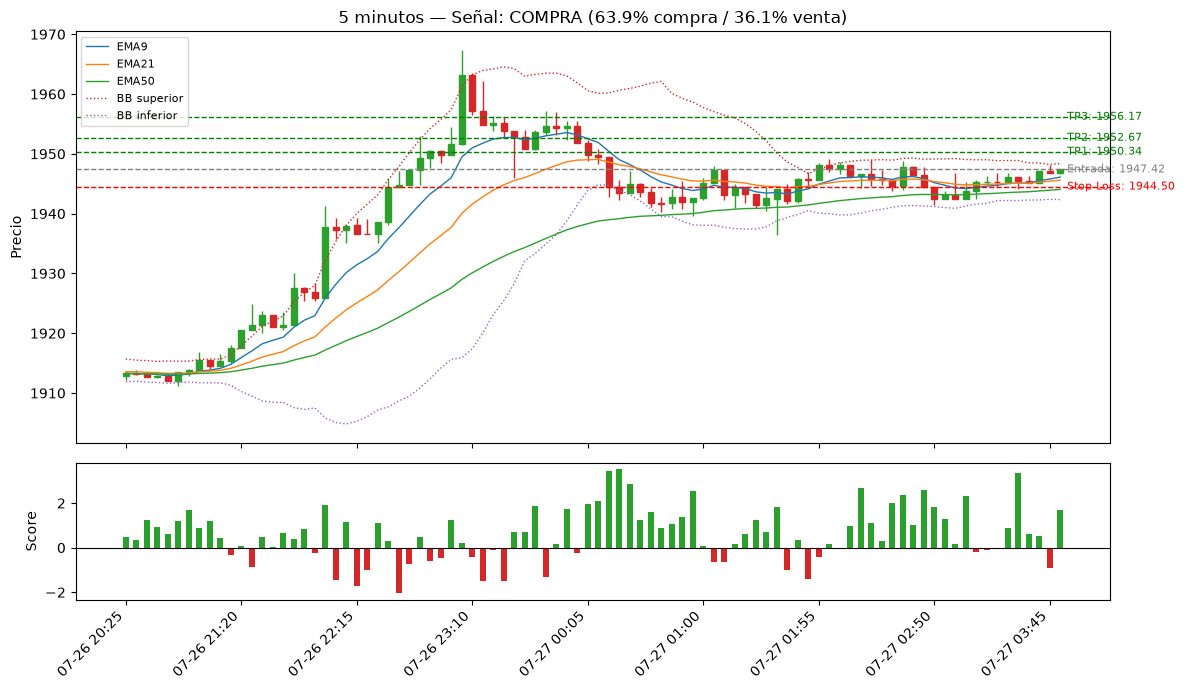

### 15 minutos (15m) — fuente: Binance (respaldo)

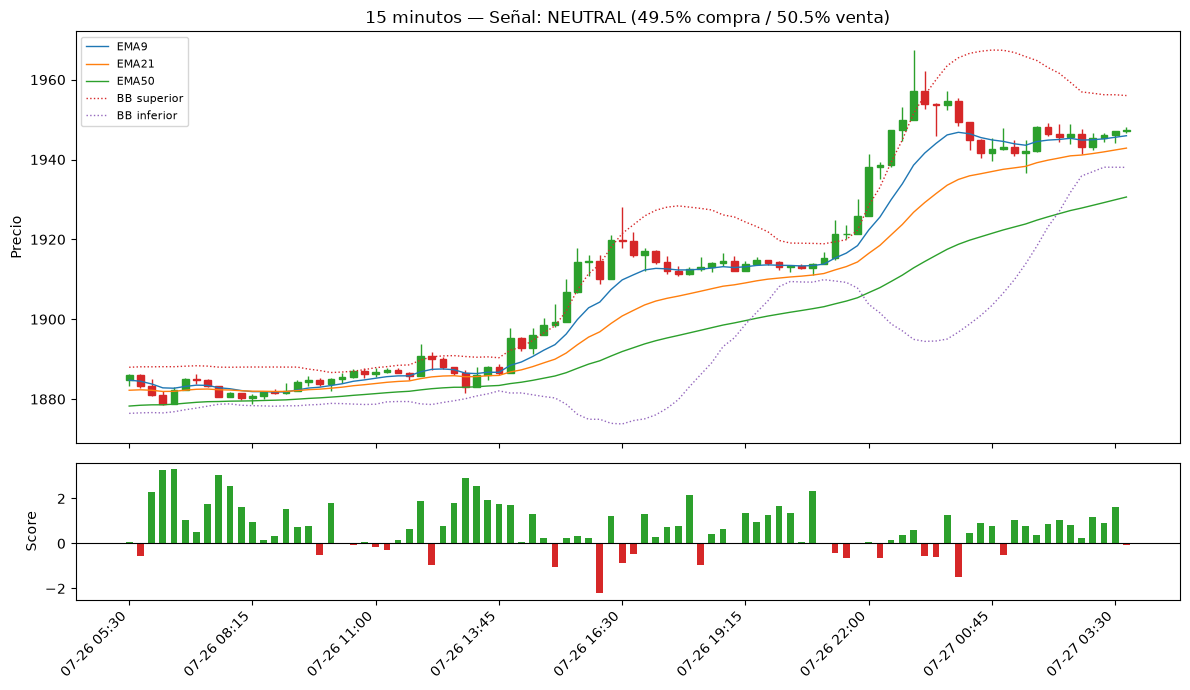

### 1 hora (1h) — fuente: Binance (respaldo)

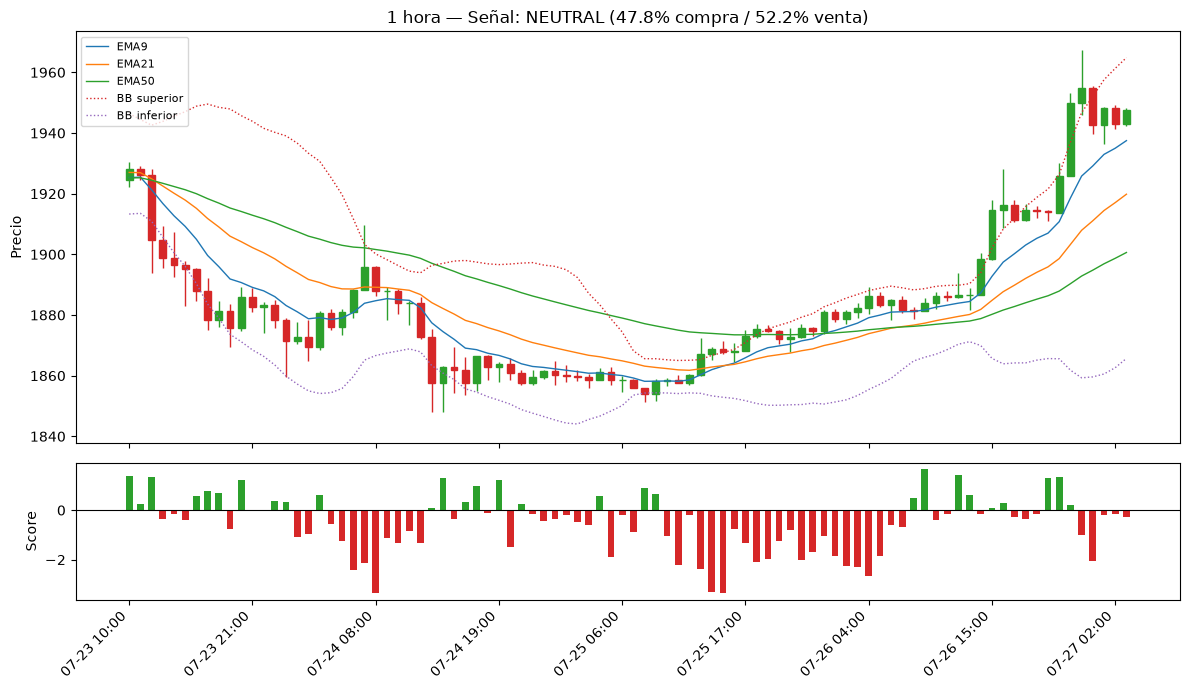

In [43]:
def graficar_velas(ax, df, ancho=0.6, color_alcista="tab:green", color_bajista="tab:red"):
    x = np.arange(len(df))
    colores = np.where(df["close"].values >= df["open"].values, color_alcista, color_bajista)
    ax.vlines(x, df["low"].values, df["high"].values, color=colores, linewidth=1)
    cuerpo_bajo = np.minimum(df["open"].values, df["close"].values)
    cuerpo_alto = np.maximum(df["open"].values, df["close"].values) - cuerpo_bajo
    ax.bar(x, cuerpo_alto, bottom=cuerpo_bajo, width=ancho, color=colores, edgecolor=colores)
    return x


def formatear_eje_x(ax, indice_tiempo, n_ticks=8):
    n = len(indice_tiempo)
    paso = max(1, n // n_ticks)
    posiciones = list(range(0, n, paso))
    etiquetas = [indice_tiempo[i].strftime("%m-%d %H:%M") for i in posiciones]
    ax.set_xticks(posiciones)
    ax.set_xticklabels(etiquetas, rotation=45, ha="right")


for etiqueta, r in resultados.items():
    df_tf, u = r["df"], r["df"].iloc[-1]
    display(Markdown(f"### {etiqueta} ({r['tf_binance']}) — fuente: {r['fuente']}"))

    fig, (ax_precio, ax_score) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                               gridspec_kw={"height_ratios": [3, 1]})
    x = graficar_velas(ax_precio, df_tf)
    ax_precio.plot(x, df_tf["ema9"], label="EMA9", linewidth=1)
    ax_precio.plot(x, df_tf["ema21"], label="EMA21", linewidth=1)
    ax_precio.plot(x, df_tf["ema50"], label="EMA50", linewidth=1)
    ax_precio.plot(x, df_tf["bb_high"], label="BB superior", linewidth=1, linestyle=":")
    ax_precio.plot(x, df_tf["bb_low"], label="BB inferior", linewidth=1, linestyle=":")

    if u["señal"] != "NEUTRAL":
        for nivel, nombre, color in [(u["entrada"], "Entrada", "gray"), (u["stop_loss"], "Stop Loss", "red"),
                                      (u["take_profit_1"], "TP1", "green"), (u["take_profit_2"], "TP2", "green"),
                                      (u["take_profit_3"], "TP3", "green")]:
            ax_precio.axhline(nivel, color=color, linestyle="--", linewidth=1)
            ax_precio.annotate(f"{nombre}: {nivel:.2f}", xy=(x[-1], nivel), xytext=(5, 0),
                                textcoords="offset points", va="center", fontsize=8, color=color)

    ax_precio.set_title(f"{etiqueta} — Señal: {u['señal']} ({u['prob_compra']}% compra / {u['prob_venta']}% venta)")
    ax_precio.set_ylabel("Precio")
    ax_precio.legend(loc="upper left", fontsize=8)

    colores_score = np.where(df_tf["score"] >= 0, "tab:green", "tab:red")
    ax_score.bar(x, df_tf["score"], color=colores_score, width=0.6)
    ax_score.axhline(0, color="black", linewidth=0.8)
    ax_score.set_ylabel("Score")

    formatear_eje_x(ax_score, df_tf.index)
    fig.tight_layout()
    plt.show()

## 10. Detalle de las últimas 90 velas por temporalidad

In [44]:
columnas = ["open", "high", "low", "close", "volume", "score", "prob_compra", "prob_venta",
            "señal", "stop_loss", "take_profit_1", "take_profit_2", "take_profit_3"]

for etiqueta, r in resultados.items():
    display(Markdown(f"### {etiqueta} ({r['tf_binance']})"))
    display(r["df"][columnas])

### 5 minutos (5m)

,open,high,low,close,volume,score,prob_compra,prob_venta,señal,stop_loss,take_profit_1,take_profit_2,take_profit_3
timestamp,,,,,,,,,,,,,
2026-07-26 20:25:00,"1,912.79","1,913.53","1,912.26","1,913.29",144.05,0.46,53.80,46.20,NEUTRAL,NaN,NaN,NaN,NaN
2026-07-26 20:30:00,"1,913.30","1,913.91","1,913.09","1,913.22",119.67,0.33,52.80,47.20,NEUTRAL,NaN,NaN,NaN,NaN
2026-07-26 20:35:00,"1,913.23","1,913.23","1,912.70","1,912.70",84.33,1.23,60.20,39.80,COMPRA,"1,911.16","1,914.24","1,915.47","1,917.32"
2026-07-26 20:40:00,"1,912.71","1,912.95","1,912.53","1,912.86",96.48,0.91,57.60,42.40,NEUTRAL,NaN,NaN,NaN,NaN
2026-07-26 20:45:00,"1,912.86","1,913.19","1,911.94","1,911.95",112.19,0.63,55.30,44.70,NEUTRAL,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-27 03:30:00,"1,946.12","1,946.12","1,944.06","1,945.49",409.74,3.36,75.60,24.40,COMPRA,"1,942.11","1,948.87","1,951.58","1,955.63"
2026-07-27 03:35:00,"1,945.48","1,946.36","1,945.11","1,945.11",229.13,0.63,55.30,44.70,NEUTRAL,NaN,NaN,NaN,NaN
2026-07-27 03:40:00,"1,945.12","1,947.13","1,945.11","1,947.13",425.93,0.53,54.50,45.50,NEUTRAL,NaN,NaN,NaN,NaN


### 15 minutos (15m)

,open,high,low,close,volume,score,prob_compra,prob_venta,señal,stop_loss,take_profit_1,take_profit_2,take_profit_3
timestamp,,,,,,,,,,,,,
2026-07-26 05:30:00,"1,884.89","1,886.40","1,883.38","1,886.05",539.47,0.08,50.70,49.30,NEUTRAL,NaN,NaN,NaN,NaN
2026-07-26 05:45:00,"1,886.05","1,886.18","1,882.72","1,883.40",919.30,-0.55,45.40,54.60,NEUTRAL,NaN,NaN,NaN,NaN
2026-07-26 06:00:00,"1,883.40","1,884.95","1,880.74","1,881.09",805.90,2.30,68.50,31.50,COMPRA,"1,877.40","1,884.78","1,887.73","1,892.15"
2026-07-26 06:15:00,"1,881.08","1,881.97","1,878.46","1,878.88",854.53,3.26,75.00,25.00,COMPRA,"1,875.16","1,882.60","1,885.58","1,890.05"
2026-07-26 06:30:00,"1,878.87","1,882.98","1,878.83","1,882.35",586.60,3.32,75.40,24.60,COMPRA,"1,878.54","1,886.16","1,889.22","1,893.79"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-27 02:45:00,"1,946.44","1,947.73","1,941.48","1,943.10","1,655.16",0.25,52.10,47.90,NEUTRAL,NaN,NaN,NaN,NaN
2026-07-27 03:00:00,"1,943.09","1,946.73","1,942.42","1,945.29","1,765.44",1.18,59.80,40.20,NEUTRAL,NaN,NaN,NaN,NaN
2026-07-27 03:15:00,"1,945.29","1,946.75","1,944.49","1,946.12","1,114.60",0.91,57.60,42.40,NEUTRAL,NaN,NaN,NaN,NaN


### 1 hora (1h)

,open,high,low,close,volume,score,prob_compra,prob_venta,señal,stop_loss,take_profit_1,take_profit_2,take_profit_3
timestamp,,,,,,,,,,,,,
2026-07-23 10:00:00,"1,924.36","1,930.43","1,922.13","1,928.14","4,239.39",1.40,61.50,38.50,COMPRA,"1,914.62","1,941.66","1,952.48","1,968.71"
2026-07-23 11:00:00,"1,928.15","1,929.08","1,924.63","1,926.04","5,003.25",0.27,52.20,47.80,NEUTRAL,NaN,NaN,NaN,NaN
2026-07-23 12:00:00,"1,926.03","1,927.99","1,894.00","1,904.64","26,669.46",1.32,60.90,39.10,COMPRA,"1,889.71","1,919.57","1,931.51","1,949.42"
2026-07-23 13:00:00,"1,904.67","1,909.19","1,895.47","1,898.72","16,334.97",-0.36,47.00,53.00,NEUTRAL,NaN,NaN,NaN,NaN
2026-07-23 14:00:00,"1,898.73","1,907.26","1,892.50","1,896.43","15,426.31",-0.17,48.50,51.50,NEUTRAL,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-26 23:00:00,"1,949.81","1,967.36","1,945.99","1,954.72","25,239.85",-1.01,41.50,58.50,NEUTRAL,NaN,NaN,NaN,NaN
2026-07-27 00:00:00,"1,954.72","1,955.42","1,939.67","1,942.54","10,815.74",-2.05,33.40,66.60,VENTA,"1,955.25","1,929.83","1,919.67","1,904.42"
2026-07-27 01:00:00,"1,942.54","1,948.46","1,936.51","1,948.20","8,651.07",-0.19,48.40,51.60,NEUTRAL,NaN,NaN,NaN,NaN


## 11. Proyección estadística de precio (Monte Carlo / Movimiento Browniano Geométrico)

Para cada temporalidad se simula la evolución futura del precio con un **Movimiento Browniano Geométrico (GBM)** — el modelo estocástico estándar en finanzas cuantitativas para activos — calibrado con la deriva (μ) y volatilidad (σ) de los rendimientos logarítmicos de las mismas 90 velas ya analizadas:

`S(t+1) = S(t) · exp((μ − σ²/2) + σ·Z)`,  con `Z ~ N(0,1)`

Se simulan `N_SIMULACIONES_MC` trayectorias hacia adelante y se calculan bandas de confianza (50% / 80% / 95%) a partir de los percentiles de esas trayectorias en cada paso futuro — el resultado es un "fan chart", el gráfico estándar para comunicar incertidumbre en proyecciones financieras.

> ⚠️ La deriva (μ) estimada con solo 90 velas es estadísticamente muy ruidosa (es un problema conocido: el retorno esperado de un activo es mucho más difícil de estimar que su volatilidad) — no interpretes hacia dónde apunta la mediana como una predicción direccional confiable. El valor principal de esta proyección está en el **ancho de las bandas de confianza** (la volatilidad esperada), útil para juzgar qué tan realistas son tus TP dado el horizonte de tiempo.

In [45]:
N_PERIODOS_PROYECCION = 12       # velas hacia adelante a proyectar
N_SIMULACIONES_MC = 3000         # trayectorias Monte Carlo por temporalidad
NIVELES_CONFIANZA = (50, 80, 95) # % de las bandas de confianza a calcular
SEMILLA_MC = 42                  # semilla para reproducibilidad

FREQ_PANDAS = {"5m": "5min", "15m": "15min", "1h": "1h"}  # frecuencia de pandas por temporalidad


def simular_montecarlo_gbm(precios, n_periodos, n_simulaciones=N_SIMULACIONES_MC, semilla=SEMILLA_MC):
    log_returns = np.diff(np.log(precios))
    mu = log_returns.mean()
    sigma = log_returns.std()
    rng = np.random.default_rng(semilla)
    shocks = rng.normal(loc=(mu - 0.5 * sigma**2), scale=sigma, size=(n_simulaciones, n_periodos))
    trayectorias = precios[-1] * np.exp(np.cumsum(shocks, axis=1))
    trayectorias = np.hstack([np.full((n_simulaciones, 1), precios[-1]), trayectorias])
    return trayectorias, mu, sigma


def calcular_bandas_confianza(trayectorias, niveles_confianza=NIVELES_CONFIANZA):
    bandas = {"mediana": np.percentile(trayectorias, 50, axis=0)}
    for nivel in niveles_confianza:
        cola = (100 - nivel) / 2
        bandas[f"ic{nivel}_low"] = np.percentile(trayectorias, cola, axis=0)
        bandas[f"ic{nivel}_high"] = np.percentile(trayectorias, 100 - cola, axis=0)
    return bandas


for etiqueta, r in resultados.items():
    precios = r["df"]["close"].values
    trayectorias, mu, sigma = simular_montecarlo_gbm(precios, N_PERIODOS_PROYECCION)
    bandas = calcular_bandas_confianza(trayectorias)
    fechas_futuras = pd.date_range(r["df"].index[-1], periods=N_PERIODOS_PROYECCION + 1,
                                    freq=FREQ_PANDAS[r["tf_binance"]])

    r["proyeccion"] = {"trayectorias": trayectorias, "bandas": bandas,
                        "fechas_futuras": fechas_futuras, "mu": mu, "sigma": sigma}

    print(f"[{etiqueta}] μ={mu:.6f} por vela | σ={sigma:.6f} por vela | "
          f"mediana a {N_PERIODOS_PROYECCION} velas: {bandas['mediana'][-1]:.2f} | "
          f"IC95%: [{bandas['ic95_low'][-1]:.2f}, {bandas['ic95_high'][-1]:.2f}]")

[5 minutos] μ=0.000199 por vela | σ=0.001323 por vela | mediana a 12 velas: 1952.07 | IC95%: [1935.28, 1969.61]
[15 minutos] μ=0.000360 por vela | σ=0.001689 por vela | mediana a 12 velas: 1955.94 | IC95%: [1934.48, 1978.40]
[1 hora] μ=0.000112 por vela | σ=0.003270 por vela | mediana a 12 velas: 1950.07 | IC95%: [1908.87, 1993.65]


## 12. Visualización de la proyección (fan chart)

### 5 minutos (5m) — proyección a 12 velas

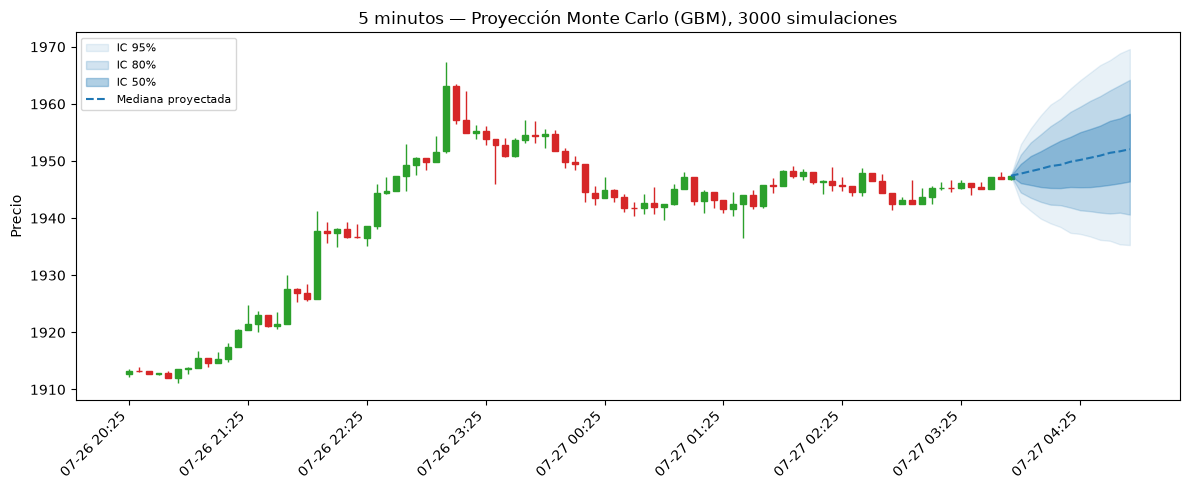

### 15 minutos (15m) — proyección a 12 velas

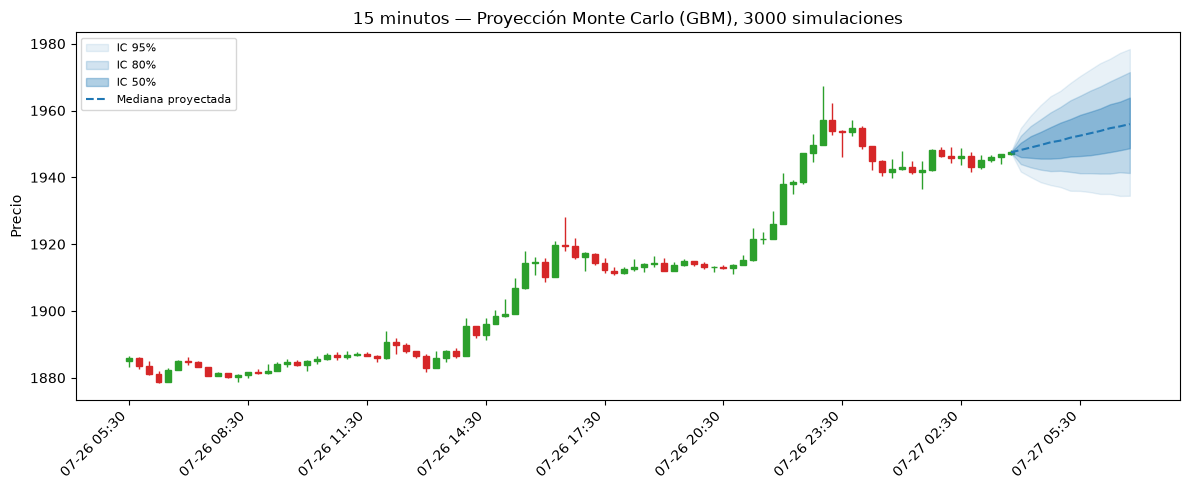

### 1 hora (1h) — proyección a 12 velas

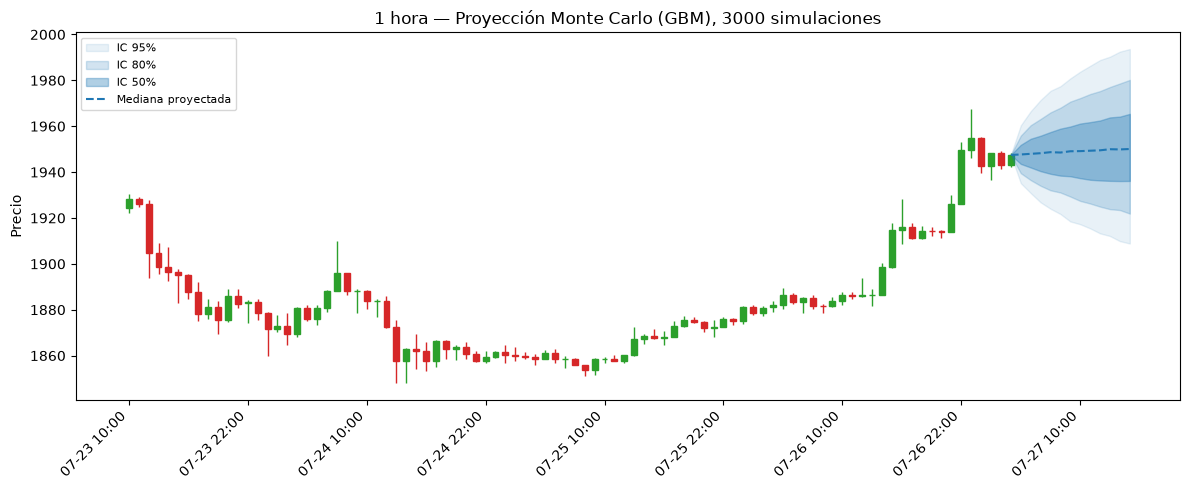

In [46]:
for etiqueta, r in resultados.items():
    df_tf = r["df"]
    bandas = r["proyeccion"]["bandas"]
    fechas_futuras = r["proyeccion"]["fechas_futuras"]

    display(Markdown(f"### {etiqueta} ({r['tf_binance']}) — proyección a {N_PERIODOS_PROYECCION} velas"))

    fig, ax = plt.subplots(figsize=(12, 5))
    graficar_velas(ax, df_tf)
    x_fut = np.arange(len(df_tf) - 1, len(df_tf) - 1 + N_PERIODOS_PROYECCION + 1)

    for nivel, alpha in {95: 0.10, 80: 0.20, 50: 0.35}.items():
        ax.fill_between(x_fut, bandas[f"ic{nivel}_low"], bandas[f"ic{nivel}_high"],
                         color="tab:blue", alpha=alpha, label=f"IC {nivel}%")
    ax.plot(x_fut, bandas["mediana"], color="tab:blue", linestyle="--", linewidth=1.5, label="Mediana proyectada")

    ax.set_title(f"{etiqueta} — Proyección Monte Carlo (GBM), {N_SIMULACIONES_MC} simulaciones")
    ax.set_ylabel("Precio")
    ax.legend(loc="upper left", fontsize=8)

    todas_fechas = pd.DatetimeIndex(list(df_tf.index) + list(fechas_futuras[1:]))
    formatear_eje_x(ax, todas_fechas)
    fig.tight_layout()
    plt.show()

## 13. ¿Qué tan alcanzables son los TP dentro del horizonte proyectado?

Compara cada nivel de Take Profit con las bandas de confianza del paso final de la proyección (a `N_PERIODOS_PROYECCION` velas), como referencia rápida de qué tan ambicioso es cada objetivo dado el ritmo de volatilidad reciente. **No** es la probabilidad de que el precio toque el TP en algún momento del camino (eso depende de la trayectoria completa, no solo del punto final) — es solo una referencia de rango esperado.

In [47]:
def clasificar_respecto_a_bandas(nivel, bandas):
    if bandas["ic50_low"][-1] <= nivel <= bandas["ic50_high"][-1]:
        return "dentro de IC 50% (muy alcanzable en este horizonte)"
    elif bandas["ic80_low"][-1] <= nivel <= bandas["ic80_high"][-1]:
        return "dentro de IC 80% (alcanzable)"
    elif bandas["ic95_low"][-1] <= nivel <= bandas["ic95_high"][-1]:
        return "dentro de IC 95% (posible pero ambicioso)"
    else:
        return "fuera de IC 95% (poco probable en este horizonte con la volatilidad reciente)"


hubo_señal = False
for etiqueta, r in resultados.items():
    ultima = r["df"].iloc[-1]
    if ultima["señal"] == "NEUTRAL":
        continue
    hubo_señal = True
    bandas = r["proyeccion"]["bandas"]
    print(f"--- {etiqueta} ({ultima['señal']}) ---")
    for nombre, nivel in [("TP1", ultima["take_profit_1"]), ("TP2", ultima["take_profit_2"]),
                           ("TP3", ultima["take_profit_3"])]:
        print(f"  {nombre} ({nivel:.2f}): {clasificar_respecto_a_bandas(nivel, bandas)}")
    print()

if not hubo_señal:
    print("Ninguna temporalidad tiene señal COMPRA/VENTA activa ahora mismo, nada que comparar.")

--- 5 minutos (COMPRA) ---
  TP1 (1950.34): dentro de IC 50% (muy alcanzable en este horizonte)
  TP2 (1952.67): dentro de IC 50% (muy alcanzable en este horizonte)
  TP3 (1956.17): dentro de IC 50% (muy alcanzable en este horizonte)

